# Семинар 1. От функции потерь к backpropagation

Сквозной пример — линейная регрессия
$$\hat y=b+wx,$$
для которой можно увидеть данные, поверхность потерь, сечения, градиент и шаг
обновления. Знакомые функции потерь не вводятся заново: BCE восстанавливается
из смысла правильного класса, а MSE и MAE используются для постановки вопросов.

## Содержание

- Организационные вопросы
- Цикл обучения и знакомые функции потерь
- Сквозной пример Годоя
- Сечения и численная производная
- Частные производные и градиент
- Обновление параметров и learning rate
- Chain rule, граф и вопросы о зависимостях
- Возвращение к sigmoid + BCE
- Проверка через PyTorch autograd
- Векторные формы, выводы и вопросы


## 0. Организационные вопросы

- Одна лекция → один семинар.
  - По исходному плану — 15 занятий.
- Для сдачи курса нужны баллы.
  - Планируется **6 домашних заданий** в формате notebook и соревнований,
    а также возможны короткие quiz перед семинарами.
  - Дедлайны жёсткие; проверяйте даты в актуальных материалах курса.
  - Если в итоге будет 5 домашних заданий, оценка вычисляется как $\operatorname{grade}_5(p)=\operatorname{clip}\left(\operatorname{round}\left(15\frac{p}{100}-5\right),0,10\right)$.
  - Если домашних заданий будет 6, используется формула из таблицы: $\operatorname{grade}_6(p)=\operatorname{clip}\left(\operatorname{round}\left(18\frac{p}{100}-6\right),0,10\right)$.
    Здесь `p` — общая сумма баллов по всем домашним заданиям.
  - Зачёт начинается с оценки 3.
  - Минимум четыре домашние работы должны быть сданы не менее чем на 10 баллов.
- За жульничество применяются санкции. В частности, нельзя:
  - копировать чужой код из notebook или передавать свой код другим;
  - использовать чужие submission в соревнованиях;
  - решать quiz за других;
  - заимствовать open-source код без указания источника.
- Связь — в Telegram.
- Всё получится.

[Оценивание](https://github.com/SergeyMalashenko/2026_ML3/blob/main/docs/grading.md)

In [1]:
from pathlib import Path
from runpy import run_path

try:
    import google.colab
except ModuleNotFoundError:
    repository_root = next(
        (root for root in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
         if (root / 'config.py').is_file() and (root / 'plots' / 'seminar01.py').is_file()),
        None,
    )
    if repository_root is None:
        raise RuntimeError('Откройте notebook из локальной копии репозитория 2026_ML3.')
else:
    repository_root = Path.cwd().resolve()
    if not Path('config.py').is_file():
        import requests

        config_url = (
            'https://raw.githubusercontent.com/'
            'SergeyMalashenko/2026_ML3/main/config.py'
        )
        try:
            response = requests.get(config_url, timeout=30)
            response.raise_for_status()
        except requests.RequestException:
            from google.colab import files
            from io import BytesIO
            from zipfile import ZipFile

            print('Файлы ещё не опубликованы. Загрузите seminar01_colab_helpers.zip.')
            uploaded = files.upload()
            if len(uploaded) != 1:
                raise RuntimeError('Выберите один архив seminar01_colab_helpers.zip.')
            required_files = (
                'config.py', 'plots/__init__.py', 'plots/seminar01.py',
                'plots/assets/training_loop.svg',
            )
            with ZipFile(BytesIO(next(iter(uploaded.values())))) as archive:
                payload = {name: archive.read(name) for name in required_files}
            for name, content in payload.items():
                destination = Path(name)
                destination.parent.mkdir(parents=True, exist_ok=True)
                destination.write_bytes(content)
        else:
            Path('config.py').write_bytes(response.content)


seminar_plots = run_path(str(repository_root / 'config.py'))['config_seminar01']()


In [2]:
from importlib.util import find_spec

required = ('numpy', 'matplotlib', 'torch')
missing = [package for package in required if find_spec(package) is None]
if missing:
    raise RuntimeError(
        f'Missing packages: {missing}. Install the shared root requirements.txt.'
    )

import numpy as np
import torch

seminar_plots.configure_plots()
np.set_printoptions(precision=5, suppress=True)

print('CPU environment | NumPy', np.__version__, '| PyTorch', torch.__version__)

CPU environment | NumPy 2.5.3 | PyTorch 2.14.0


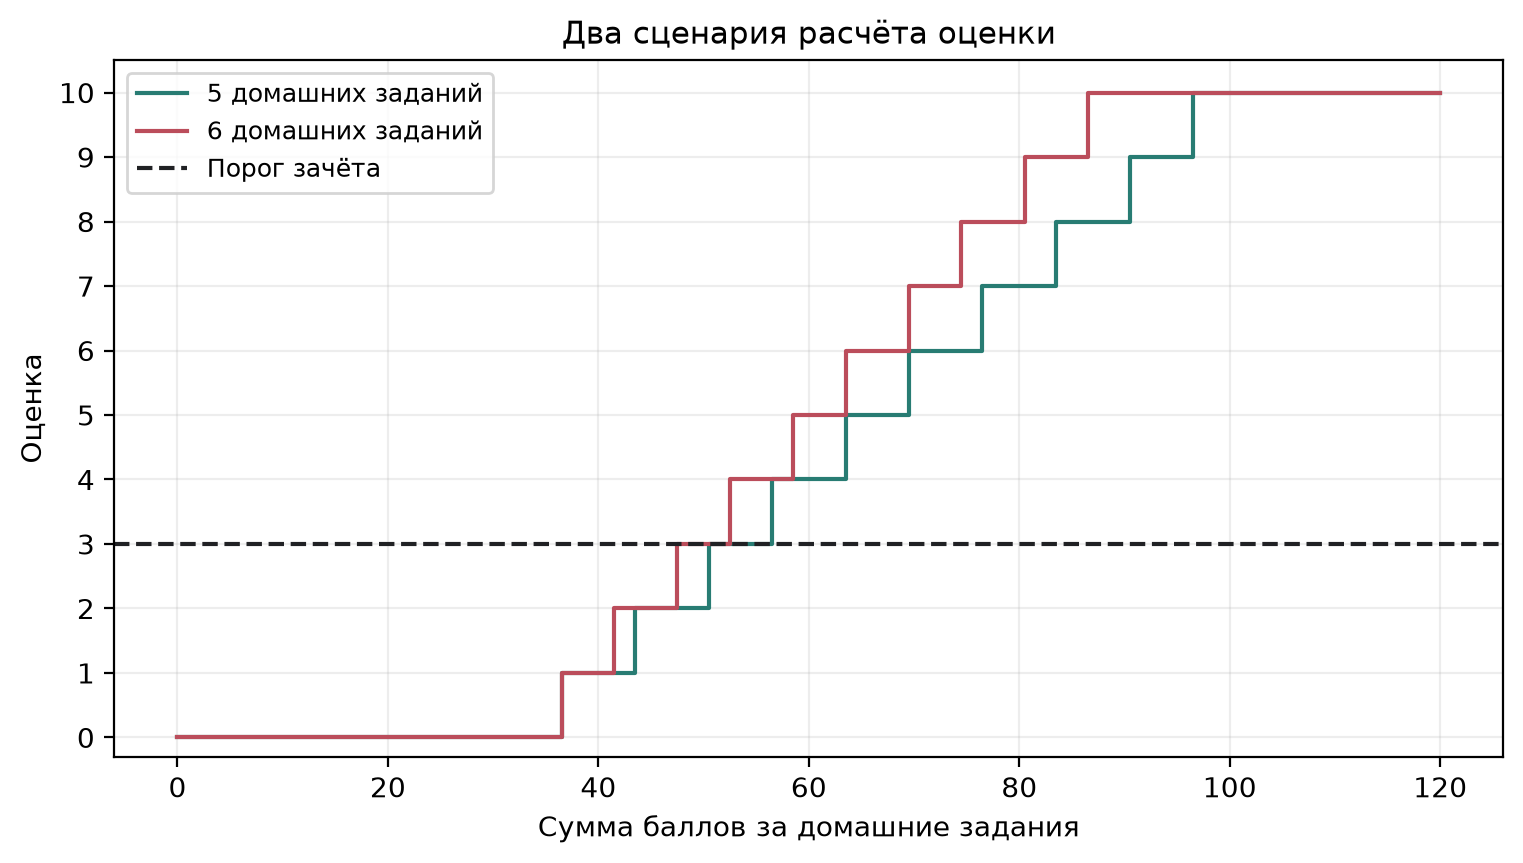

In [3]:
def grade(total_points, homework_count):
    """Оценка по сумме баллов; округление половин к чётному, как в NumPy."""
    if homework_count not in (5, 6):
        raise ValueError('Количество домашних заданий должно быть 5 или 6.')
    points = np.asarray(total_points, dtype=float)
    if np.any(~np.isfinite(points)) or np.any(points < 0):
        raise ValueError('Баллы должны быть конечными неотрицательными числами.')
    result = np.clip(np.rint(3 * homework_count * points / 100 - homework_count), 0, 10)
    return int(result) if result.ndim == 0 else result.astype(int)


total_points = np.arange(0, 121)
seminar_plots.plot_grades(total_points, grade(total_points, 5), grade(total_points, 6))

## 1. Цикл обучения и знакомые потери

$$x_i\xrightarrow{f_\theta}\hat y_i
\xrightarrow{\ell(y_i,\hat y_i)}\ell_i
\xrightarrow{\frac1n\sum_i}L
\xrightarrow{\nabla_\theta L}\theta_{new}.$$

$\ell_i$ — потеря одного объекта; $L(\theta)=\frac1n\sum_{i=1}^n\ell(y_i,f_\theta(x_i))$ — средняя потеря по выборке.

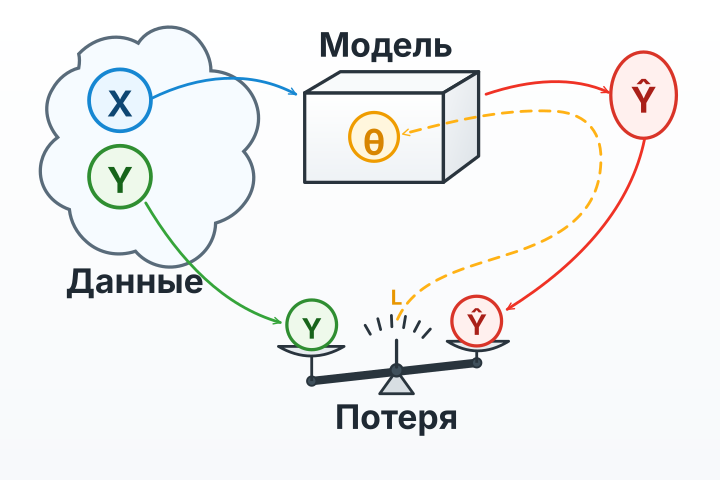

In [4]:
seminar_plots.plot_training_loop()

Модели ML - это параметризованные функции, которые (как правило) в качестве аргумента принимают объекты данных: 
* Векторы признаков, 
* Тензоры изображений / аудио / ..., 
* Последовательности токенов для текстов, ...

Выходы функции интерпретируются как "предсказания" (*predictions*), которые вместе с известными правильными ответами (*ground truth*) используются для корректировки параметров функции в процессе обучения.

Для того, чтобы численно оценить, насколько ответы модели соответствуют правде, используются функции потерь (*loss functions*):
* Для регрессии: 
  * Mean Squared Error: $\text{MSE}(y, \hat{y}) = \frac1n\sum_{i=1}^n(y_i-\hat y_i)^2$,
  * Mean Absolute Error: $\text{MAE}(y, \hat{y}) = \frac1n\sum_{i=1}^n|y_i-\hat y_i|$,
  * ...
* Для классификации:
  * (Binary) Cross Entropy Loss: $\text{BCE}(y, \hat{y}) = \dots$
  * Hinge Loss, Focal Loss, \<YOUR LOSS\>, ...


В цикле обучения сначала получаем предсказание, затем оцениваем его ошибку.
Вспомним, как эти два шага устроены в бинарной классификации.

Линейная часть модели вычисляет число

$$
z = b + w_1x_1 + w_2x_2.
$$

Оно может быть любым, а нам нужна вероятность класса 1.

В логистической регрессии $z$ моделирует логарифм шансов:

$$
z = \log\frac{p}{1-p}.
$$

**Выразите $p$ через $z$. Какую знакомую функцию получили?**

Теперь перейдём от предсказания к потере. Допустим, модель оценила
вероятность класса 1 как $p=0.9$.

- Истинная метка — 1. Какую вероятность модель присвоила истинному классу?
- А если истинная метка — 0?
- В каком случае потеря должна быть больше?
- Какую функцию от вероятности истинного класса мы используем в BCE?

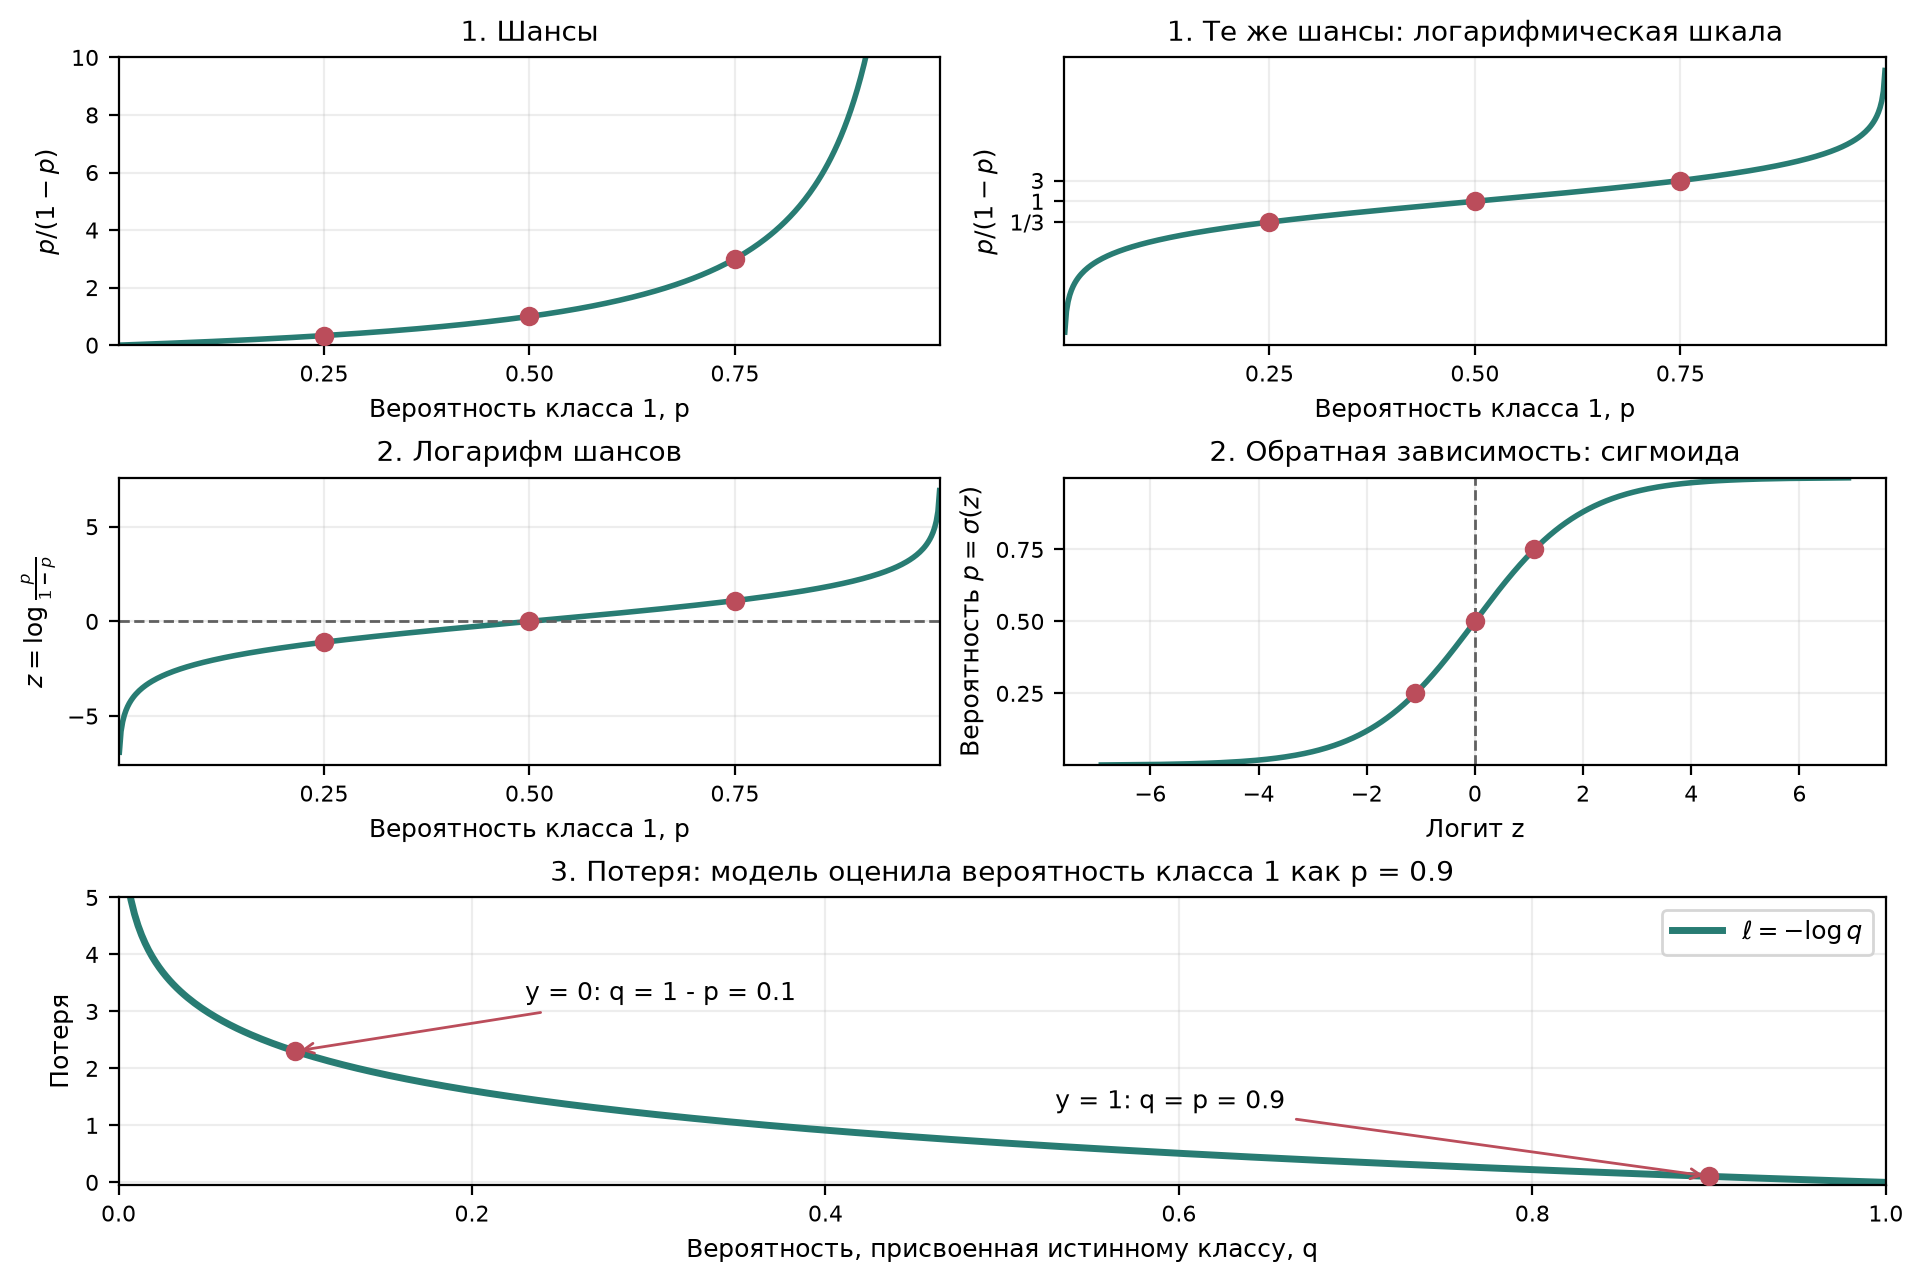

In [5]:
p = np.linspace(0.001, 0.999, 500)
seminar_plots.plot_bce(p)

Для положительного объекта правильная вероятность равна $p$, для отрицательного —
$1-p$. Поэтому

$$
\ell(y,p)=
\begin{cases}
-\log p, & y=1,\\
-\log(1-p), & y=0.
\end{cases}
$$

Индикаторы $y$ и $1-y$ объединяют два случая:

$$\ell(y,p)=-y\log p-(1-y)\log(1-p).$$

Это ход Годоя: сначала две очевидные суммы по объектам правильного класса,
затем компактная формула. Мы вернёмся к ней после chain rule.

In [ ]:
labels = np.array([1., 0.])
probabilities = np.array([.9, .2])
per_item = -(labels*np.log(probabilities) + (1-labels)*np.log(1-probabilities))
print('losses:', per_item)
print('mean BCE:', per_item.mean())

### Вопрос перед рисунком: что сделает далёкий выброс?

Пусть модель предсказывает одну константу $c$.

- Оптимум MSE — среднее.
- Оптимум MAE — медиана.

Предскажите, как изменятся оба оптимума, если одну точку постепенно отодвигать
от остальных до расстояния $10^6$.

In [ ]:
inliers = np.array([-1.0, -0.25, 0.3, 0.8])
outlier_distance = np.logspace(0, 6, 300)
samples = np.column_stack([
    np.broadcast_to(inliers, (outlier_distance.size, inliers.size)),
    outlier_distance,
])

mse_optimum = samples.mean(axis=1)
mae_optimum = np.median(samples, axis=1)
reference_prediction = np.median(np.r_[inliers, 1.0])
mse_influence = 2*np.abs(outlier_distance-reference_prediction)
mae_influence = np.ones_like(outlier_distance)

seminar_plots.plot_outlier_influence(outlier_distance, mse_optimum, mae_optimum, mse_influence, mae_influence)

Это сразу объясняет и устойчивость: **выброс может находиться хоть в миллионе
километров, но у него всё равно один голос**. У MSE влияние точки растёт с
расстоянием, поэтому далёкий выброс сильнее тянет предсказание к себе.

Точнее, вне точки излома производная отдельной потери $\ell=|c-y|$ по константе имеет
модуль 1, а для $\ell=(c-y)^2$ модуль производной равен $2|c-y|$. В средней потере $L$ каждый вклад дополнительно делится на $n$. В точке $c=y$ у MAE
используется субградиент; это не меняет рассуждение об ограниченном влиянии.

## 2. Сквозной пример Годоя

$$y=b+wx+\varepsilon.$$

Мы знаем истинные параметры только потому, что сами генерируем данные. Обучение
увидит лишь пары $(x_i,y_i)$ и будет подбирать $b,w$.

**Вопросы до запуска:**

- Мы восстановили истинные $b$ и $w$. Будут ли предсказания точно совпадать с наблюдаемыми $y$? Что останется в ошибке?
- Ошибка на обучающих данных уменьшилась. Достаточно ли этого, чтобы утверждать, что модель стала лучше предсказывать новые данные?

In [ ]:
true_b, true_w = 1.0, 2.0
n = 100

rng = np.random.RandomState(42)
x = rng.rand(n, 1)
noise = 0.1*rng.randn(n, 1)
y = true_b + true_w*x + noise

indices = rng.permutation(n)
train_indices = indices[:80]
validation_indices = indices[80:]
x_train, y_train = x[train_indices], y[train_indices]
x_validation, y_validation = x[validation_indices], y[validation_indices]

seminar_plots.plot_data(x_train, y_train, x_validation, y_validation, true_b, true_w)

In [ ]:
rng_parameters = np.random.RandomState(42)
b_initial = float(rng_parameters.randn(1)[0])
w_initial = float(rng_parameters.randn(1)[0])

def predict_numpy(x_values, parameters):
    b_value, w_value = np.asarray(parameters)
    return b_value + w_value*x_values

def mse_numpy(parameters, x_values=x_train, y_values=y_train):
    residuals = predict_numpy(x_values, parameters)-y_values
    return float(np.mean(residuals**2))

parameters_initial = np.array([b_initial, w_initial])
predictions_initial = predict_numpy(x_train, parameters_initial)
loss_initial = mse_numpy(parameters_initial)
print('initial parameters [b, w]:', parameters_initial)
print('initial train MSE:', loss_initial)

In [ ]:
seminar_plots.plot_initial_model(x_train, y_train, true_b, true_w, parameters_initial, predict_numpy, loss_initial)

## 3. Один параметр, сечения и численная производная

Loss является функцией параметров:

$$L(b,w)=\frac1n\sum_i(b+wx_i-y_i)^2.$$

Чтобы увидеть влияние одного параметра, фиксируем второй и делаем сечение
поверхности потерь. Это центральная интуиция Chapter 0 Годоя.

**До рисунка:** в какую сторону от случайной точки нужно изменить $b$? А $w$?
Какое сечение выглядит более крутым?

In [ ]:
b_range = np.linspace(true_b-3, true_b+3, 151)
w_range = np.linspace(true_w-3, true_w+3, 151)
bs, ws = np.meshgrid(b_range, w_range)

predictions_grid = bs[None, :, :] + ws[None, :, :]*x_train.reshape(-1, 1, 1)
errors_grid = predictions_grid-y_train.reshape(-1, 1, 1)
losses_grid = np.mean(errors_grid**2, axis=0)

loss_by_b = np.array([mse_numpy([value, w_initial]) for value in b_range])
loss_by_w = np.array([mse_numpy([b_initial, value]) for value in w_range])

design = np.column_stack([np.ones(x_train.size), x_train.ravel()])
optimal_parameters = np.linalg.lstsq(design, y_train.ravel(), rcond=None)[0]

seminar_plots.plot_loss_landscape(
    bs, ws, losses_grid, parameters_initial, optimal_parameters,
    b_range, w_range, loss_by_b, loss_by_w, b_initial, w_initial
)

### Численная производная — измерение наклона

$$\frac{\partial L}{\partial w}\approx
\frac{L(b,w+h)-L(b,w)}{h}.$$

- Какой знак ожидается для обеих компонент в начальной точке?
- Почему изменение только $w$ является частной, а не полной производной?
- Всегда ли уменьшение $h$ улучшает ответ?

In [ ]:
def forward_gradient(function, point, h):
    point = np.asarray(point, dtype=float)
    result = []
    for basis_vector in np.eye(point.size):
        result.append((function(point+h*basis_vector)-function(point))/h)
    return np.array(result)

def central_gradient(function, point, h):
    point = np.asarray(point, dtype=float)
    result = []
    for basis_vector in np.eye(point.size):
        result.append(
            (function(point+h*basis_vector)-function(point-h*basis_vector))/(2*h)
        )
    return np.array(result)

errors_initial = predictions_initial-y_train
analytic_gradient = np.array([
    2*errors_initial.mean(),
    2*(x_train*errors_initial).mean(),
])

print('forward, h=0.12:', forward_gradient(mse_numpy, parameters_initial, .12))
print('central, h=1e-5:', central_gradient(mse_numpy, parameters_initial, 1e-5))
print('analytic:', analytic_gradient)

In [ ]:
steps = np.logspace(-1, -14, 14)
forward_errors = np.array([
    np.linalg.norm(forward_gradient(mse_numpy, parameters_initial, h)-analytic_gradient)
    for h in steps
])
central_errors = np.array([
    np.linalg.norm(central_gradient(mse_numpy, parameters_initial, h)-analytic_gradient)
    for h in steps
])

seminar_plots.plot_difference_error(steps, forward_errors, central_errors)

## 4. Частные производные и градиент

Для одного объекта $e_i=b+wx_i-y_i$, а для среднего квадрата ошибок

$$
\frac{\partial L}{\partial b}=\frac2n\sum_i e_i,
\qquad
\frac{\partial L}{\partial w}=\frac2n\sum_i x_i e_i.
$$

Градиент собирает обе чувствительности:

$$\nabla_{(b,w)}L=
\begin{bmatrix}L_b\\L_w\end{bmatrix}.$$

**Вопросы:** почему в $L_w$ появляется $x_i$? Почему ошибки усредняются?
Можно ли вычислить $L_w$, не вычисляя сначала $L_b$?

In [ ]:
numeric_gradient = central_gradient(mse_numpy, parameters_initial, 1e-5)
np.testing.assert_allclose(analytic_gradient, numeric_gradient, atol=1e-8)

print('analytic gradient:', analytic_gradient)
print('numeric gradient: ', numeric_gradient)
print('component with larger magnitude:', ['b', 'w'][np.argmax(np.abs(analytic_gradient))])

## 5. Обновление параметров и learning rate

$$\theta_{new}=\theta-\eta\nabla_\theta L.$$

Градиент отвечает на вопрос «куда растёт loss», знак минус меняет направление,
а learning rate определяет длину шага.

**Перед запуском:** какой из шагов, вероятнее всего, почти ничего не изменит?
Какой может перескочить полезную область? Верный градиент гарантирует уменьшение
loss при любом $\eta$?

In [ ]:
learning_rates = np.logspace(-3, .35, 250)
loss_after_step = np.array([
    mse_numpy(parameters_initial-lr*analytic_gradient) for lr in learning_rates
])
shown_rates = [.02, .1, .8]

seminar_plots.plot_learning_rates(
    bs, ws, losses_grid, parameters_initial, analytic_gradient,
    shown_rates, learning_rates, loss_after_step, loss_initial, mse_numpy
)

## 6. Chain rule и вычислительный граф

Для одного наблюдения используем удобные числа:

$$x=0.5,\quad y=2,\quad b=0.5,\quad w=1,$$
$$m=wx,\quad \hat y=b+m,\quad e=\hat y-y,\quad \ell=e^2.$$

Слово «влияет» будем разделять на три разных вопроса:

1. Зависит ли **значение выхода** от переменной?
2. Зависит ли **численное значение конкретной производной** от переменной?
3. Находится ли узел на пути от дифференцируемой переменной к выходу?

Сначала выполните только следующую ячейку со структурой графа.

In [ ]:
seminar_plots.plot_graph_structure()

### Вопросы аудитории по структуре

Отвечайте «да / нет» и называйте путь или промежуточное значение.

1. Влияет ли $y$ на предсказание $\hat y$? Влияет ли $y$ на loss?
2. Влияет ли $b$ на произведение $m$? Влияет ли $b$ на loss?
3. Сколько путей ведёт от $w$ к loss?
4. Нужно ли вычислить $\partial\ell/\partial b$, чтобы найти
   $\partial\ell/\partial w$?
5. Может ли значение $b$ влиять на численное значение
   $\partial\ell/\partial w$, хотя производная по $b$ для этого не нужна?
6. Какие значения forward нужно сохранить для backward?

Перед раскрытием forward вычислите $m$, $\hat y$, $e$ и $\ell$.

**Ваши ответы:** $m=\ldots$, $\hat y=\ldots$, $e=\ldots$, $\ell=\ldots$.

In [ ]:
seminar_plots.plot_graph_forward()

### Перед backward

Внутри узла остаётся значение прямого прохода. Под узлом $v$ записываем
$\partial\ell/\partial v$: чувствительность конечной потери к этому значению.
На связи $u\to v$ множитель равен $\partial v/\partial u$.

**Идём назад. На ребре умножаем. Пришедшие в один узел вклады складываем.**

$$\text{Вклад в }\frac{\partial\ell}{\partial u}=
\frac{\partial\ell}{\partial v}\cdot\frac{\partial v}{\partial u}.$$

Предскажите:

- с какого числа начинается backward у самой потери и почему;
- знак $\partial\ell/\partial\hat y$;
- совпадут ли производные по $b$ и $w$;
- какие значения прямого прохода понадобятся на пути к $w$.

**Ваши ответы:** $\partial\ell/\partial\ell=\ldots$,
$\partial\ell/\partial b=\ldots$, $\partial\ell/\partial w=\ldots$.

Перед каждым следующим шагом предложите множитель на ребре и результат.
Статический вариант рисунка: `seminar_plots.plot_graph_backward(step=0)`; шаги от 0 до 8.

In [ ]:
seminar_plots.plot_graph_backward()

### Разбор «влияет / не влияет»

- $y$ не влияет на $\hat y$, но влияет на $e$ и loss.
- $b$ не влияет на $m=wx$, но влияет на $\hat y$, $e$ и loss.
- $\partial\ell/\partial w=2ex$ можно вычислить независимо от
  $\partial\ell/\partial b=2e$.
- При этом **значение** $b$ влияет на $\partial\ell/\partial w$, потому что
  $e=b+wx-y$ зависит от $b$.
- Это не означает, что нужна производная по $b$: нужны сохранённые forward-значения
  $x$ и $e$ и общий обратный сигнал $\partial\ell/\partial\hat y$.

Именно поэтому вопрос «влияет ли $b$?» без уточнения неоднозначен.

Производные по данным $x,y$ помогают прочитать весь граф, но данные мы не обновляем.
При проходе назад через сложение сигнал передаётся каждому слагаемому.
Если одно значение использовано в нескольких операциях, вернувшиеся к нему вклады складываются.

### Где появляется сумма вкладов

Один параметр $w$ используется для всех объектов batch. Значит, от него идёт
несколько ветвей к общей средней потере.

**Вопрос:** градиент по $w$ определяется самым трудным объектом или суммой вкладов?
Что изменится, если заменить `mean` на `sum`?

Сначала два отдельных учебных объекта: $b=0.5$, $w=1$,
$(x_1,y_1)=(0.5,2)$, $(x_2,y_2)=(1,1)$ и $L=(\ell_1+\ell_2)/2$.

**До раскрытия:** сколько путей ведёт от $w$ к $L$? Что получит каждая потеря
при обратном проходе через среднее? Можно ли остановиться после первой ветви?

**Ваши ответы:** первый вклад $\ldots$, второй вклад $\ldots$, сумма $\ldots$.
Статический вариант: `seminar_plots.plot_batch_graph(step=0)`; шаги от 0 до 5.

In [ ]:
seminar_plots.plot_batch_graph()

In [ ]:
per_item_b = 2*errors_initial.ravel()
per_item_w = 2*(x_train*errors_initial).ravel()
order = np.argsort(x_train.ravel())

seminar_plots.plot_batch_contributions(x_train, per_item_b, per_item_w, order)

## 7. Возвращение к sigmoid + BCE

Пусть модель выдаёт logit $z$, а $p=\sigma(z)$. Для знакомой BCE

$$\frac{\partial\ell}{\partial p}
=-\frac{y}{p}+\frac{1-y}{1-p},
\qquad
\frac{\partial p}{\partial z}=p(1-p).$$

По chain rule выражение неожиданно сокращается:

$$\boxed{\frac{\partial\ell}{\partial z}=p-y}.$$

**Вопросы:** при $y=1,p=0.9$ сигнал положительный или отрицательный? Куда шаг
градиентного спуска изменит $z$? Что получится при $y=0,p=0.2$?

In [ ]:
p_grid = np.linspace(.001, .999, 500)
seminar_plots.plot_bce_gradient(p_grid)

## 8. Проверка через PyTorch autograd

Конечные разности были независимым измерением, ручные формулы — аналитическим
расчётом. Теперь просим PyTorch выполнить тот же backward по построенному графу.

`backward()` вычисляет градиенты; параметры он не обновляет.

In [ ]:
x_tensor = torch.tensor(x_train, dtype=torch.float64)
y_tensor = torch.tensor(y_train, dtype=torch.float64)
parameters_tensor = torch.tensor(parameters_initial, dtype=torch.float64, requires_grad=True)

predictions_tensor = parameters_tensor[0] + parameters_tensor[1]*x_tensor
loss_tensor = ((predictions_tensor-y_tensor)**2).mean()
loss_tensor.backward()

autograd_gradient = parameters_tensor.grad.detach().numpy().copy()
np.testing.assert_allclose(autograd_gradient, analytic_gradient, atol=1e-12)
np.testing.assert_allclose(autograd_gradient, numeric_gradient, atol=1e-8)

print('manual:            ', analytic_gradient)
print('finite differences:', numeric_gradient)
print('PyTorch autograd:  ', autograd_gradient)

In [ ]:
learning_rate = .1
parameters_updated = parameters_initial-learning_rate*autograd_gradient
loss_updated = mse_numpy(parameters_updated)

seminar_plots.plot_update(
    x_train, y_train, true_b, true_w, parameters_initial,
    parameters_updated, predict_numpy, loss_initial, loss_updated
)

print('before [b, w]:', parameters_initial)
print('gradient:     ', autograd_gradient)
print('after [b, w]: ', parameters_updated)

## 9. Векторные формы

Пусть $z=Ax$ — промежуточный вектор вычислительного графа, а $L$ — общая средняя потеря, зависящая от $z$. Обозначим
$\delta=\nabla_zL$. Тогда

$$J_{z,x}=A,\qquad
\nabla_xL=A^T\delta,\qquad
\nabla_AL=\delta x^T.$$

### Вопросы о формах

- Если $A\in\mathbb R^{m\times n}$, какой формы $J_{z,x}$?
- Какой формы $\nabla_xL$?
- Почему $\nabla_AL$ имеет ту же форму, что и $A$?
- Где здесь полный якобиан, а где vector–Jacobian product, реально нужный backward?

In [ ]:
A = np.array([[1., 2., -1.], [0., 3., 2.]])
x_vector = np.array([1., -1., 2.])
delta = np.array([2., -1.])

dx = A.T @ delta
dA = np.outer(delta, x_vector)

assert dx.shape == x_vector.shape
assert dA.shape == A.shape
print('A:', A.shape, '| x:', x_vector.shape, '| delta:', delta.shape)
print('dL/dx:', dx, '| shape:', dx.shape)
print('dL/dA:\n', dA, '| shape:', dA.shape)

## Итог

1. Loss превращает качество предсказания в скаляр.
2. Производная измеряет локальную чувствительность loss.
3. Конечные разности дают независимую проверку, но не масштабируются на большие модели.
4. Градиент собирает частные производные по параметрам.
5. Chain rule перемножает локальные производные вдоль пути.
6. В разветвлённом графе вклады складываются.
7. Backprop эффективно переиспользует промежуточные результаты.
8. `backward()` вычисляет градиенты, а optimizer использует их для обновления.

Главный контрольный вопрос: можете ли вы для любого ребра графа сказать,
какое forward-значение и какая локальная производная понадобятся на backward?

## Источники

Материалы Годоя:
[Chapter 0](https://github.com/dvgodoy/PyTorchStepByStep/blob/master/Chapter00.ipynb),
[Chapter 1](https://github.com/dvgodoy/PyTorchStepByStep/blob/master/Chapter01.ipynb),
[Chapter 3](https://github.com/dvgodoy/PyTorchStepByStep/blob/master/Chapter03.ipynb).